In [2]:
from sclsd.core.config import LSDConfig
from sclsd.train import LSD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import numpy as np

import scanpy as sc
import seaborn as sns


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/projects/apour/.cache/tmp/ipykernel_2837254/1731831613.py:7: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata_unseen.layers["raw"] = adata_unseen.X.copy()


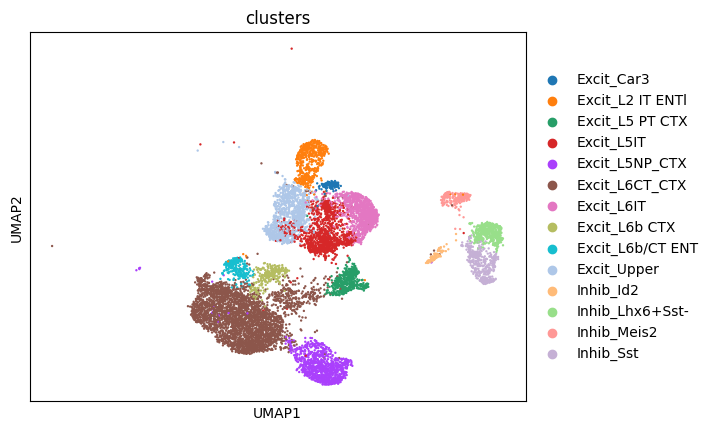

In [3]:
#read the unseen adata
adata_unseen = sc.read("../../Zenodo/Mouse_Cortex/adata_heldout.h5ad")
#read the seen_adata
adata_seen = sc.read("../../Zenodo/Mouse_Cortex/preprocessed_adata_train.h5ad")
#preprocess the unseen adata
adata_unseen = adata_unseen[:, adata_seen.var_names]
adata_unseen.layers["raw"] = adata_unseen.X.copy()
adata_unseen.obs['librarysize'] = adata_unseen.X.sum(axis = 1)
sc.pp.normalize_total(adata_unseen, target_sum= 1e4)
sc.pp.log1p(adata_unseen)
sc.pp.neighbors(adata_unseen)
sc.pl.umap(adata_unseen, color = ["clusters"])

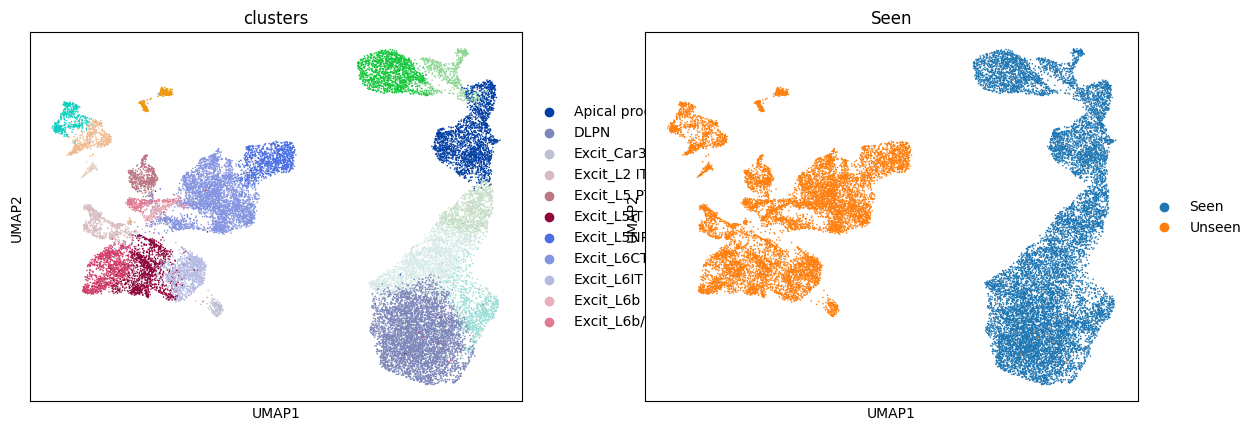

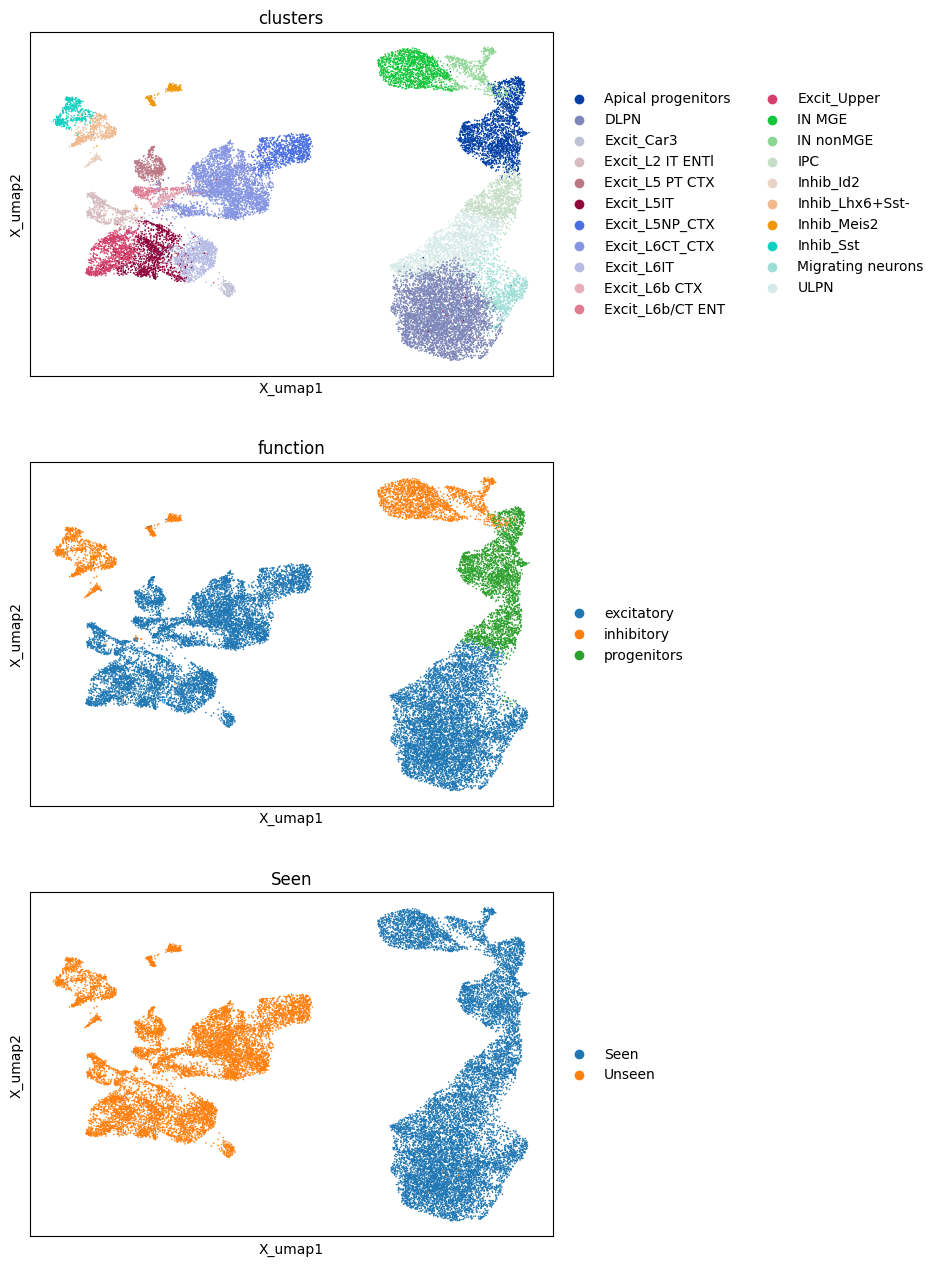

In [4]:
#combine the two adatas to get LSD predictions
adata_combined = sc.concat(
    [adata_seen, adata_unseen],
    label='Seen', 
    keys=['Seen', 'Unseen']
)

sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)
sc.pl.umap(adata_combined, color = ["clusters","Seen" ])

#map the clusters to their broad function
excitatory = ["DLPN", "ULPN", "Migrating neurons", 'Excit_Car3', 'Excit_L2 IT ENTl','Excit_L5 PT CTX', 
              'Excit_L5IT', 'Excit_L5NP_CTX','Excit_L6CT_CTX', 'Excit_L6IT', 'Excit_L6b CTX','Excit_L6b/CT ENT', 'Excit_Upper']
inhibitory = ['IN nonMGE', "IN MGE",'Inhib_Id2', 'Inhib_Lhx6+Sst-', 'Inhib_Meis2', 'Inhib_Sst']
progenitors = ["Apical progenitors", "IPC"]
# Define conditions based on membership in each list
conditions = [
    adata_combined.obs['clusters'].isin(excitatory),
    adata_combined.obs['clusters'].isin(inhibitory),
    adata_combined.obs['clusters'].isin(progenitors)
]

# Define corresponding labels
choices = ['excitatory', 'inhibitory', 'progenitors']

# Create the new 'celltype' column; cells not meeting any condition will be labeled 'unknown'
adata_combined.obs['function'] = np.select(conditions, choices, default='unknown')


sc.pl.embedding(    
    adata_combined,
    color= ['clusters', 'function', "Seen"],
    basis="X_umap",
    ncols = 1
    )

[LSD] Model and Pyro parameters loaded from ./model/lsd_model_epoch0100.pth


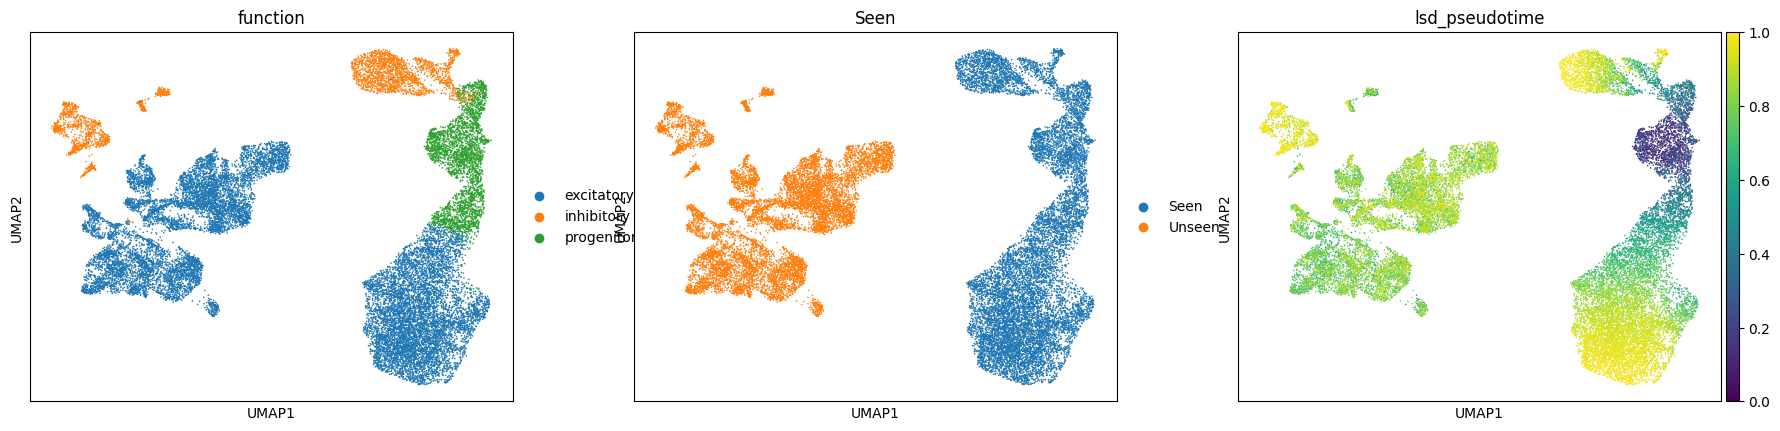

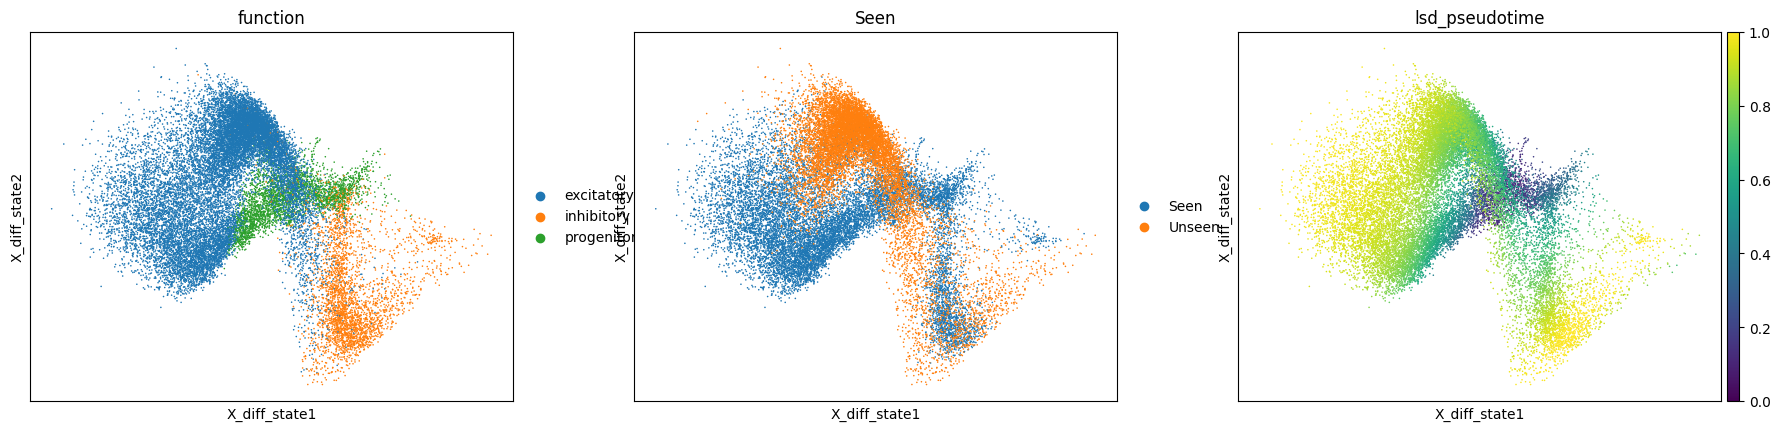

In [5]:
#get LSD preductions using the model trained only on adata_seen
cfg = LSDConfig()
cfg.model.layer_dims.potential = [16,16]
lsd = LSD(
    adata_combined,
    cfg,
    device=device,
)

#load the trained model
model_dir = "./model"
model_path = "lsd_model_epoch0100.pth"
lsd.load(model_dir, model_path)
#apply LSD to combined adata
valid_adata = lsd.get_adata()
# visualize lsd_pseudotime on UMAP
sc.pl.umap(valid_adata , color = ["function", "Seen", "lsd_pseudotime"])
#visualize differentiation state
sc.pl.embedding(valid_adata , color = ["function", "Seen", "lsd_pseudotime"], basis = "X_diff_state")

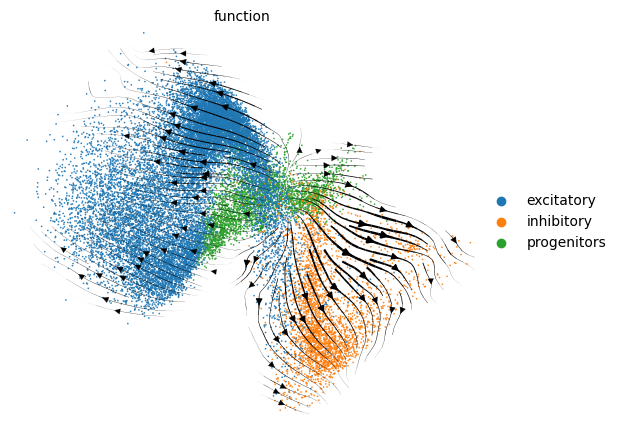

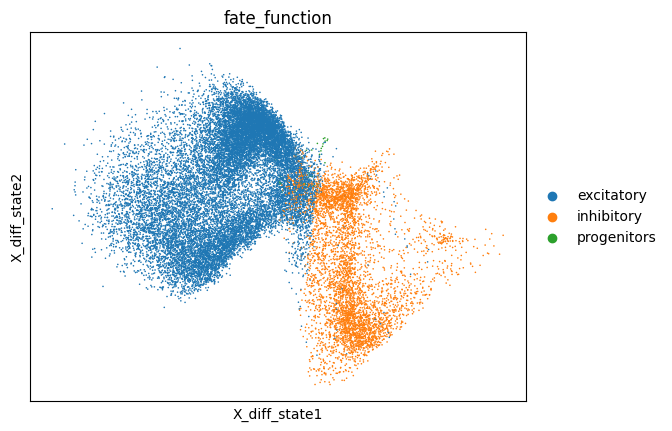

In [6]:
#visualize streamlines
lsd.stream_lines(embedding="X_diff_state", color = "function")
#get predicted cell fates
dyn_adata = lsd.get_cell_fates(
    valid_adata,
    time_range=20,          # Simulate for 100 time units
    dt=0.2,                  # Integration time step
    batch_size=4096,          # Process in batches for memory efficiency
    cluster_key="clusters",  # Use cluster annotations
    return_paths=False       # Don't return full trajectories (saves memory)
)
#get the broad function of predicted fates
conditions = [
    dyn_adata.obs['fate'].isin(excitatory),
    dyn_adata.obs['fate'].isin(inhibitory),
    dyn_adata.obs['fate'].isin(progenitors)
]

# Define corresponding labels
choices = ['excitatory', 'inhibitory', 'progenitors']

# Create the new 'celltype' column; cells not meeting any condition will be labeled 'unknown'
dyn_adata.obs['fate_function'] = np.select(conditions, choices, default='unknown')
sc.pl.embedding(dyn_adata, color = ["fate_function"], basis = "X_diff_state")

<Axes: xlabel='fate_function', ylabel='function'>

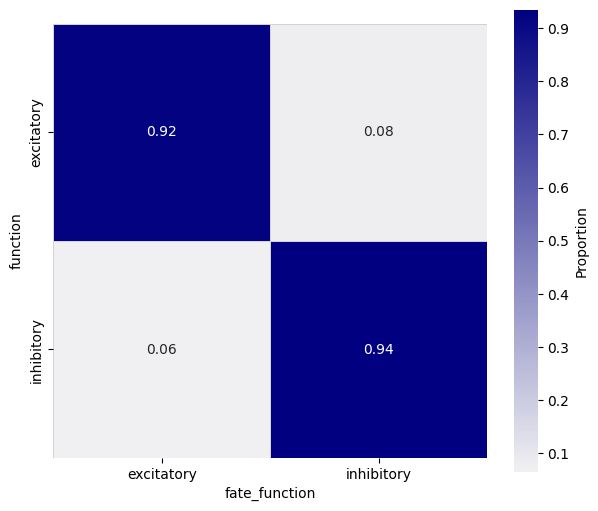

In [7]:
#plot the confusion matrix for fate function prediction accuracy
unseen = dyn_adata[dyn_adata.obs["Seen"] == "Unseen"]
confusion_unseen = pd.crosstab(
    unseen.obs["function"],
    unseen.obs["fate_function"],
    normalize='index'
)
plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_unseen,
    annot=True,
    fmt=".2f",
    cmap=sns.light_palette("navy", as_cmap=True),
    linewidths=0.5,
    linecolor='lightgrey',
    square=True,
    cbar_kws={'label': 'Proportion'}
)